In [1]:
import json
import numpy as np
import pandas as pd
import statistics as st
import matplotlib.pyplot as plt
import seaborn as sn

from pathlib import Path

plt.rcParams['figure.figsize'] = [12.5, 5]
# sn.set_theme(style="darkgrid", font_scale=2)
sn.set_theme(style="ticks")

In [2]:
# directory of the experiment
# DATASET = "fashionmnist"
DATASET = "cifar10"
DATASET = "cifar100"

# TEST = "energize_power_10_cifar10"
# TEST = "energize_power_10_skip_connections_cifar10"
# TEST = "energize_power_10_seed_cifar10"


# TEST = "energize_power_10_cifar100"
# TEST = "energize_power_10_skip_connections_cifar100"
# TEST = "energize_power_10_seed_cifar100"

# TEST = "energize_power_10"
# TEST = "energize_power_100"
# TEST = "energize_power_10_skip_connections"
# TEST = "energize_power_10_seed"
# TEST = "energize_power_lexicase"
# TEST = "energize_power_auto_eps_lexicase"
# TEST = "energize_power_10_floats"
# TEST = "energize_acc_slash_power"
# TEST = "energize_power_norm_seed"
TEST = "energize_power_10_freeze_cifar100"


TEST_DIR = f"../experiments/{DATASET}/{TEST}"

runs_dirs = tuple(i for i in Path(TEST_DIR).iterdir() if i.is_dir())
# runs_dirs = tuple(i for i in Path(TEST_DIR).iterdir() if i.is_dir() and str(i).endswith('run_0'))
n = len(runs_dirs)

layer_types = ('conv', 'batch_norm', 'pool_avg', 'pool_max', 'dropout', 'fc')
layer_types = tuple(f"layer:{i}" for i in layer_types)
# data = [None] * n_runs
simple_fields = ('id', 'phenotype', 'num_epochs', 'is_valid_solution',
                 'fitness', 'n_trainable_parameters', 'n_layers',
                 'total_epochs_trained', 'total_training_time_allocated', 'training_time_spent')
columns = ['run', 'gen', *simple_fields, 'accuracy_0', 'accuracy_1', 'n_layers_0', 'n_layers_1',
                             'power_train',
                             'power_test_0_mean', 'power_test_0_std', 'power_test_1_mean', 'power_test_1_std',
                             'energy_train',
                             'energy_test_0_mean', 'energy_test_0_std', 'energy_test_1_mean', 'energy_test_1_std',
                             'partition_point', 'batch_size']
if TEST.endswith('floats'):
    columns.append('data_type')
data = pd.DataFrame(columns=columns)
data.head()

,run,gen,id,phenotype,num_epochs,is_valid_solution,fitness,n_trainable_parameters,n_layers,total_epochs_trained,...,power_test_0_std,power_test_1_mean,power_test_1_std,energy_train,energy_test_0_mean,energy_test_0_std,energy_test_1_mean,energy_test_1_std,partition_point,batch_size


In [3]:
# adds all data into a pd.DataFrame
for run in runs_dirs:
    gens_dir = tuple(i for i in Path(run).glob('statistics/*.json'))
    run = int(run.name[run.name.find('_')+1:])
    for gen in gens_dir:
        if str(gen).split('/')[-1] == "test_accuracies.json":
            continue
        with open(gen) as file:
            gen_data = json.load(file)
        gen = int(gen.name[gen.name.find('_')+1:gen.name.find('.')])
        # if gen > 149:
        #     continue
        for ind in gen_data:
            pairs = ind['phenotype'].split()
            phenotype_dict = dict(pair.split(':') for pair in pairs)
            partition_point = int(phenotype_dict.get('partition_point'))
            batch_size = int(phenotype_dict.get('batch_size'))
            data_type = phenotype_dict.get('data_type')
            if ind['is_valid_solution']:
                power = [ind['power']['train']['power'],
                        ind['power']['test']['partition_0']['power']['mean'], ind['power']['test']['partition_0']['power']['std'], ind[
                            'power']['test']['partition_1']['power']['mean'], ind['power']['test']['partition_1']['power']['std'],
                        ind['power']['train']['energy'],
                        ind['power']['test']['partition_0']['energy']['mean'], ind['power']['test']['partition_0']['energy']['std'], ind[
                            'power']['test']['partition_1']['energy']['mean'], ind['power']['test']['partition_1']['energy']['std']]
                other_info = [ind['accuracy'][1], ind['accuracy'][2], ind['n_layers'][1], ind['n_layers'][2]]
            else:
                power = [np.nan] * 10
                other_info = [np.nan] * 4
            row_data = [run, gen, *(ind[field] for field in simple_fields),
                                   *other_info,
                                   *power,
                                   partition_point, batch_size]
            if data_type is not None:
                row_data.append(data_type)
            data.loc[len(data)] = row_data
data = data[data['is_valid_solution']]
data['power_test_diff'] = data['power_test_0_mean'] - \
    data['power_test_1_mean']  # positive is better
for layer_type in layer_types:
    count = data['phenotype'].str.count(layer_type)
    n_layers = data['n_layers_0']
    if layer_type == 'fc':
        count -= 1
        n_layers -= 1
    data[layer_type] = count / n_layers

In [4]:
data.groupby('run')['gen'].max()

run
0    118
1    123
Name: gen, dtype: int64

In [5]:
def calculate_ratio(threshold_0, threshold_1):
    filtered_data = data[
        (data['accuracy_0'] > threshold_0) &
        (data['accuracy_1'] > threshold_1)
    ]
    return len(filtered_data) / len(data)

# Initial thresholds
threshold_0 = 0.05

# Desired ratio
desired_ratio = 0.64

# Binary search for threshold_0
low, high = 0.0, 1.0
while high - low > 0.0001:
    mid = (low + high) / 2
    ratio = calculate_ratio(mid, mid+0.05)
    if ratio < desired_ratio:
        high = mid
    else:
        low = mid
threshold_0 = (low + high) / 2



print(f"Threshold for accuracy_0: {threshold_0}")
print(f"Ratio: {calculate_ratio(threshold_0, threshold_0+0.05)}")

Threshold for accuracy_0: 0.022613525390625
Ratio: 0.6386630532971996


In [6]:
if TEST == "energize_power_norm_seed":
    def normalize(group):
        acc_norm = (group['accuracy_0'] - group['accuracy_0'].min()) / (group['accuracy_0'].max() - group['accuracy_0'].min())
        power_norm = (group['power_test_0_mean'] - group['power_test_0_mean'].min()) / (group['power_test_0_mean'].max() - group['power_test_0_mean'].min())
        power_norm = 1 - power_norm
        group['fitness'] = acc_norm + power_norm
        return group

    data = data.groupby('run', group_keys=False).apply(normalize)

In [7]:
best_indices = data.groupby(['run', 'gen'])['fitness'].idxmax()
best_rows_df = data.loc[best_indices]
data = best_rows_df.reset_index(drop=True)
data.head()

,run,gen,id,phenotype,num_epochs,is_valid_solution,fitness,n_trainable_parameters,n_layers,total_epochs_trained,...,energy_test_1_std,partition_point,batch_size,power_test_diff,layer:conv,layer:batch_norm,layer:pool_avg,layer:pool_max,layer:dropout,layer:fc
0,0,0,2,layer:batch_norm input:-1 layer:fc act:linear ...,132,True,0.1026,5257730,"[8, 7, 4]",132,...,4.895934,2,236,1.154136,0.0,0.142857,0.0,0.0,0.142857,0.714286
1,0,1,0,layer:batch_norm input:-1 layer:fc act:linear ...,135,True,0.1150,5257730,"[8, 7, 4]",135,...,4.102458,2,236,2.653300,0.0,0.142857,0.0,0.0,0.142857,0.714286
2,0,2,1,layer:batch_norm input:-1 layer:fc act:linear ...,129,True,0.1052,6043612,"[9, 8, 4]",129,...,4.320946,2,236,1.907636,0.0,0.125000,0.0,0.0,0.125000,0.750000
3,0,3,1,layer:batch_norm input:-1 layer:fc act:linear ...,121,True,0.1016,5257730,"[8, 7, 6]",121,...,4.390895,4,236,0.263927,0.0,0.142857,0.0,0.0,0.142857,0.714286
4,0,4,4,layer:batch_norm input:-1 layer:fc act:linear ...,245,True,0.1322,5257730,"[8, 7, 6]",245,...,4.892251,4,236,1.956833,0.0,0.142857,0.0,0.0,0.142857,0.714286


In [8]:
best = data.iloc[data['fitness'].idxmax()]

print(f"Run {best['run']} Gen {best['gen']} Fitness {best['fitness']}")
print(best['phenotype'])
print(best)

Run 1 Gen 122 Fitness 0.9235308433002817
layer:conv out_channels:59 kernel_size:5 stride:1 padding:same act:relu bias:True input:-1 layer:conv out_channels:227 kernel_size:2 stride:1 padding:valid act:linear bias:True input:0 layer:batch_norm input:1 layer:conv out_channels:108 kernel_size:2 stride:1 padding:same act:relu bias:False input:2 layer:conv out_channels:178 kernel_size:4 stride:1 padding:same act:relu bias:True input:3 layer:batch_norm input:4 layer:batch_norm input:5 layer:batch_norm input:6 layer:conv out_channels:236 kernel_size:5 stride:2 padding:same act:linear bias:True input:7 layer:conv out_channels:157 kernel_size:2 stride:1 padding:valid act:sigmoid bias:True input:8 layer:pool_avg kernel_size:4 stride:1 padding:valid input:9 layer:batch_norm input:10 layer:batch_norm input:11 layer:pool_avg kernel_size:4 stride:1 padding:valid input:12 layer:batch_norm input:13 layer:fc act:softmax out_features:100 bias:True input:14 learning:gradient_descent lr:0.0199912967987539

In [9]:
data.to_csv(f"{TEST_DIR}/data.csv", index=False)

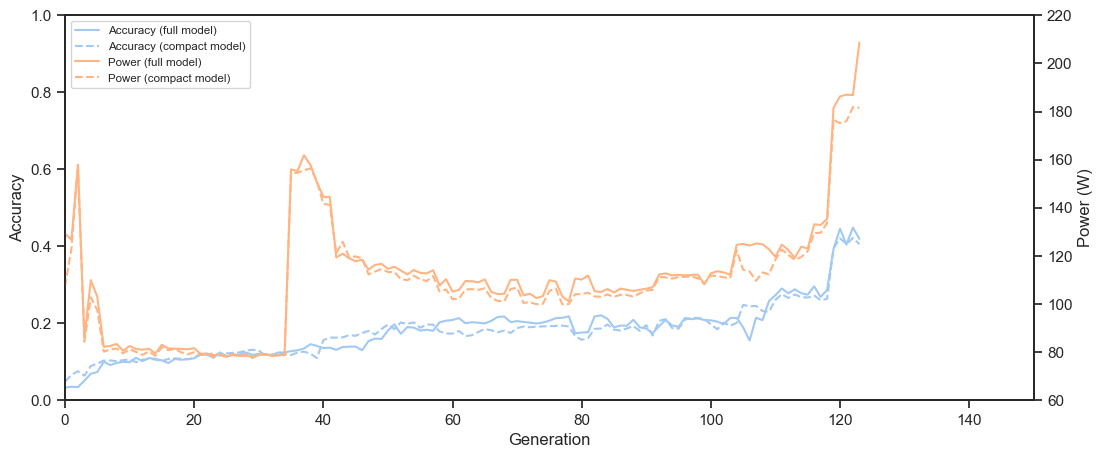

In [11]:
fig, ax1 = plt.subplots()

palette = sn.color_palette("pastel", 2) * 2
palette.sort()

sn.lineplot(data, x='gen', y='accuracy_0', label='Accuracy (full model)', ax=ax1, color=palette[0], linestyle='-', errorbar=None)
sn.lineplot(data, x='gen', y='accuracy_1', label='Accuracy (compact model)', ax=ax1, color=palette[1], linestyle='--', errorbar=None)
ax1.set_xlabel("Generation")
ax1.set_ylabel("Accuracy")
ax1.set_ylim(0, 1)

ax2 = ax1.twinx()
sn.lineplot(data=data, x='gen', y='power_test_0_mean', label='Power (full model)', ax=ax2, color=palette[2], linestyle='-', errorbar=None)
sn.lineplot(data=data, x='gen', y='power_test_1_mean', label='Power (compact model)', ax=ax2, color=palette[3], linestyle='--', errorbar=None)
ax2.set_ylabel("Power (W)")
ax2.set_ylim(60, 220)


if TEST == "energize_power_10_seed":
    ax1.set_xlim(0, 50)
    ax2.set_xlim(0, 50)
else:
    ax1.set_xlim(0, 150)
    ax2.set_xlim(0, 150)

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left', fontsize='x-small')
ax2.get_legend().remove()

plt.savefig(f"figures/{TEST}_accuracypower.pdf", bbox_inches='tight')
plt.show()

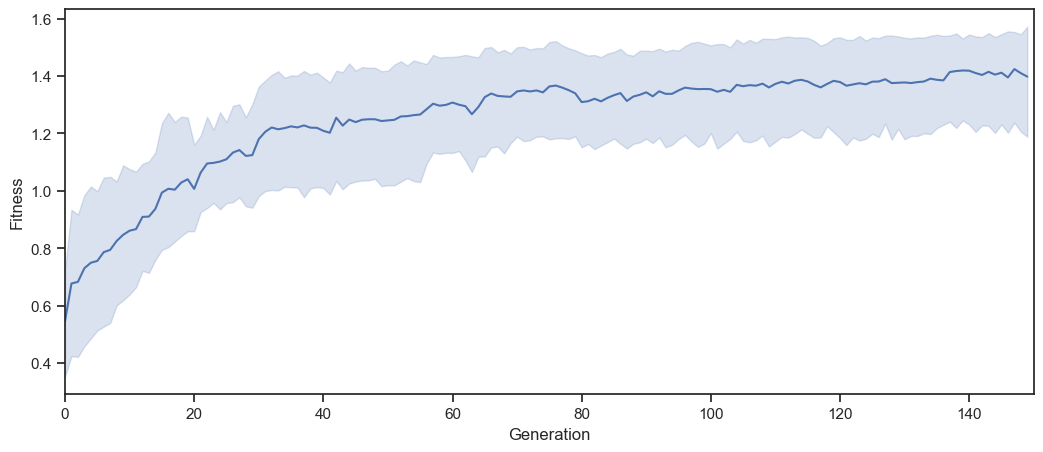

In [11]:
sn.lineplot(data, x='gen', y='fitness')
plt.xlabel("Generation")
plt.ylabel("Fitness")
plt.xlim(0, 150)
plt.show()

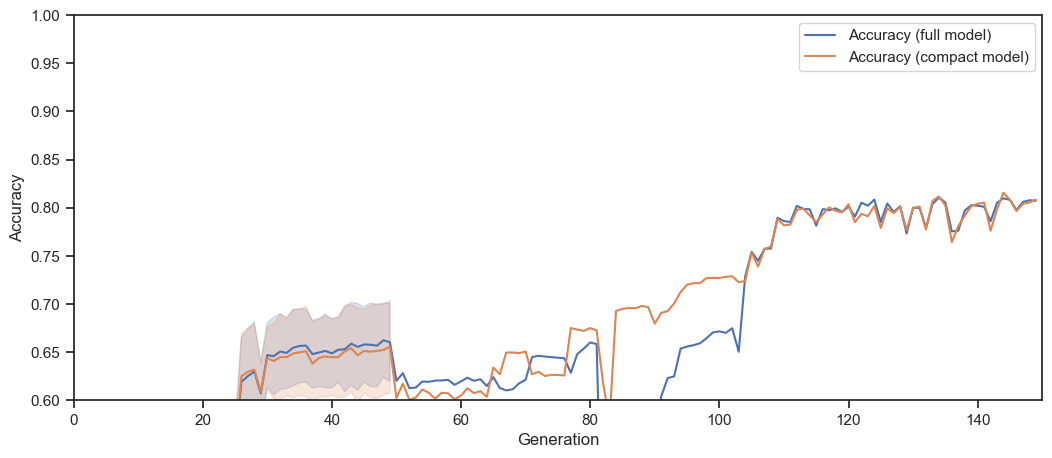

In [11]:
sn.lineplot(data, x='gen', y='accuracy_0', label='Accuracy (full model)')
sn.lineplot(data, x='gen', y='accuracy_1', label='Accuracy (compact model)')
plt.xlabel("Generation")
plt.ylabel("Accuracy")
if TEST == "energize_power_10_seed":
    plt.xlim(0, 50)
else:
    plt.xlim(0, 150)
plt.ylim(0.6, 1)
plt.savefig(f"figures/{TEST}_accuracy.pdf", bbox_inches='tight')
plt.show()

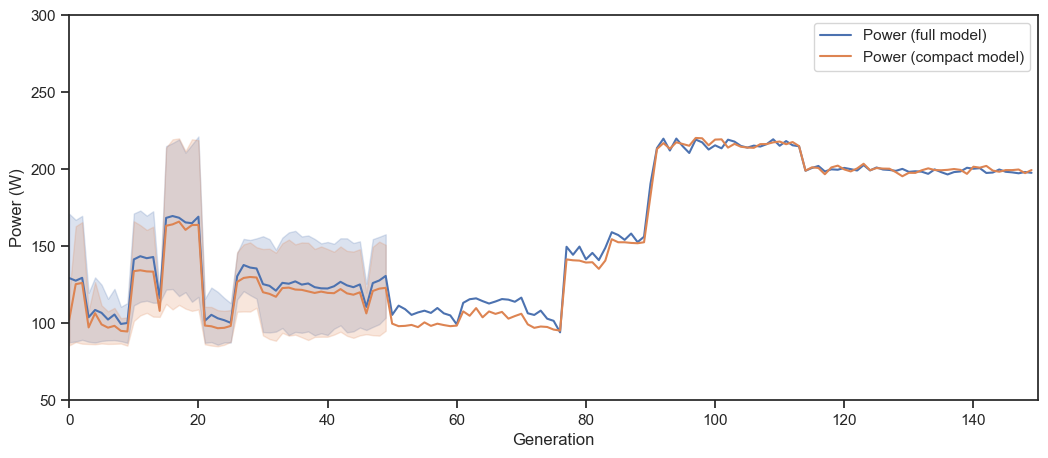

In [12]:
sn.lineplot(data, x='gen', y='power_test_0_mean', label='Power (full model)')
sn.lineplot(data, x='gen', y='power_test_1_mean', label='Power (compact model)')
plt.xlabel("Generation")
plt.ylabel("Power (W)")
if TEST == "energize_power_10_seed":
    plt.xlim(0, 50)
else:
    plt.xlim(0, 150)
plt.ylim(50, 300)
plt.savefig(f"figures/{TEST}_power.pdf", bbox_inches='tight')
plt.show()

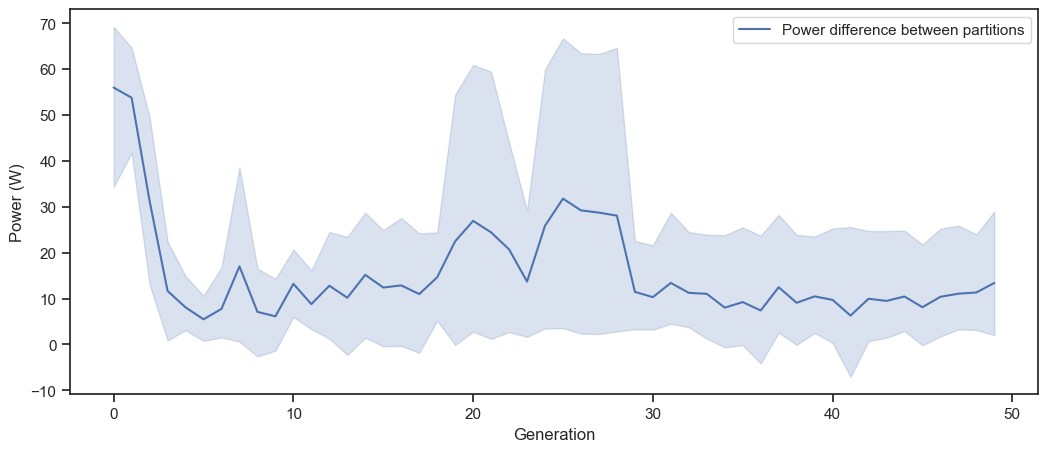

In [101]:
sn.lineplot(data, x='gen', y='power_test_diff', label='Power difference between partitions')
plt.xlabel("Generation")
plt.ylabel("Power (W)")
plt.show()

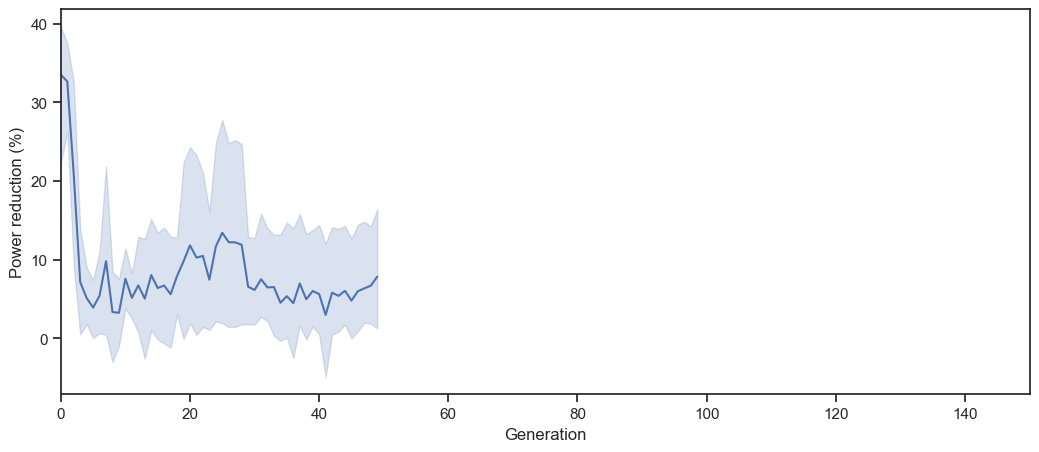

In [102]:
data['power_test_diff_percent'] = (data['power_test_0_mean'] - data['power_test_1_mean']) / data['power_test_0_mean'] * 100

sn.lineplot(data, x='gen', y='power_test_diff_percent', label='Power difference between partitions')
plt.xlabel("Generation")
plt.ylabel("Power reduction (%)")
if TEST == "energize_power_10_seed":
    plt.xlim(0, 50)
else:
    plt.xlim(0, 150)
plt.legend().remove()
plt.savefig(f"figures/{TEST}_power_diff_percent.pdf", bbox_inches='tight')
plt.show()

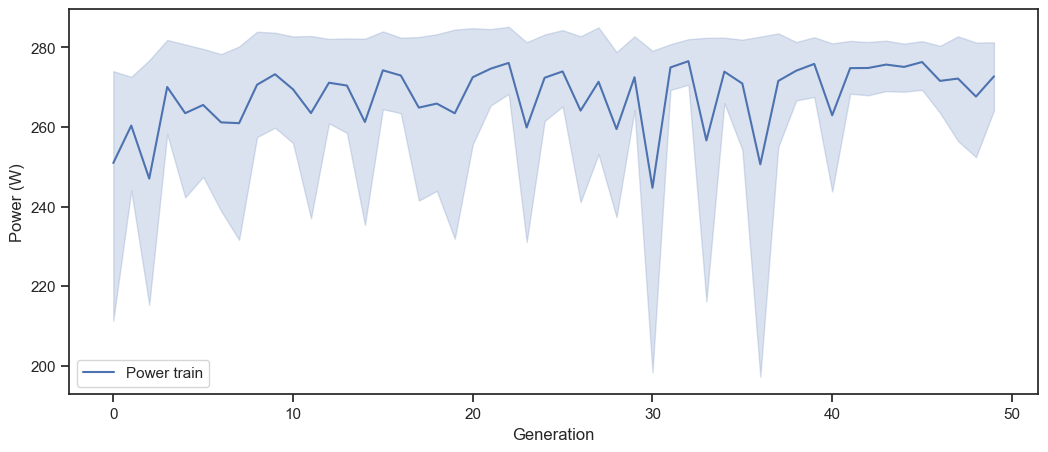

In [103]:
sn.lineplot(data, x='gen', y='power_train', label='Power train')
plt.xlabel("Generation")
plt.ylabel("Power (W)")
plt.show()

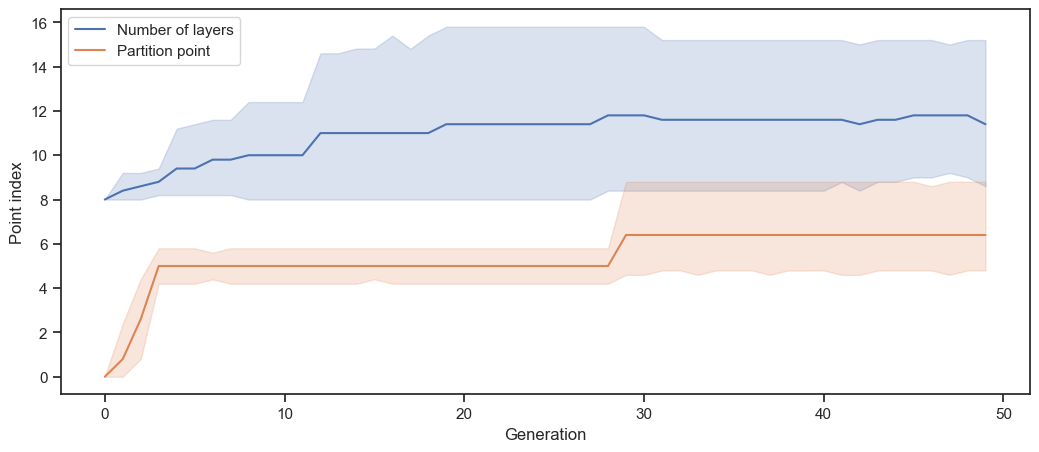

In [104]:
sn.lineplot(data, x='gen', y='n_layers_0', label='Number of layers')
sn.lineplot(data, x='gen', y='partition_point', label='Partition point')
plt.xlabel("Generation")
plt.ylabel("Point index")
plt.show()

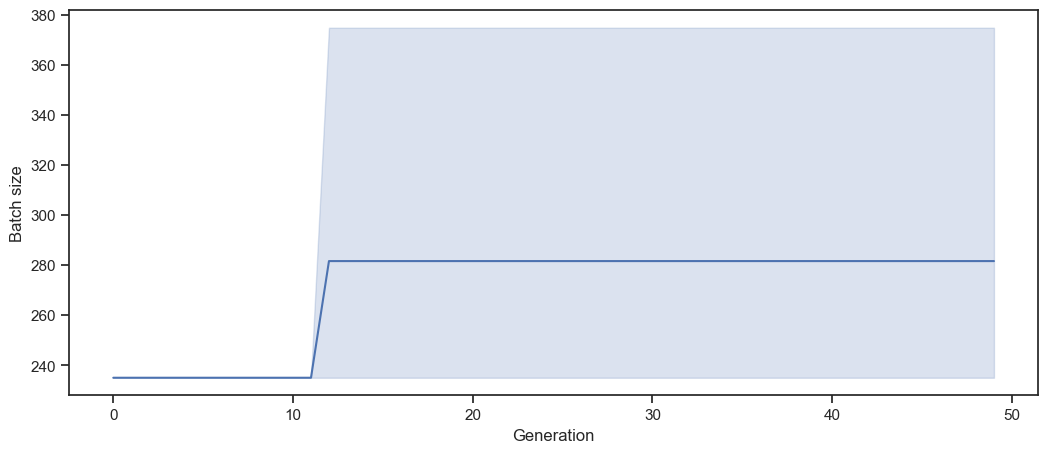

In [105]:
sn.lineplot(data, x='gen', y='batch_size')
plt.xlabel("Generation")
plt.ylabel("Batch size")
plt.show()

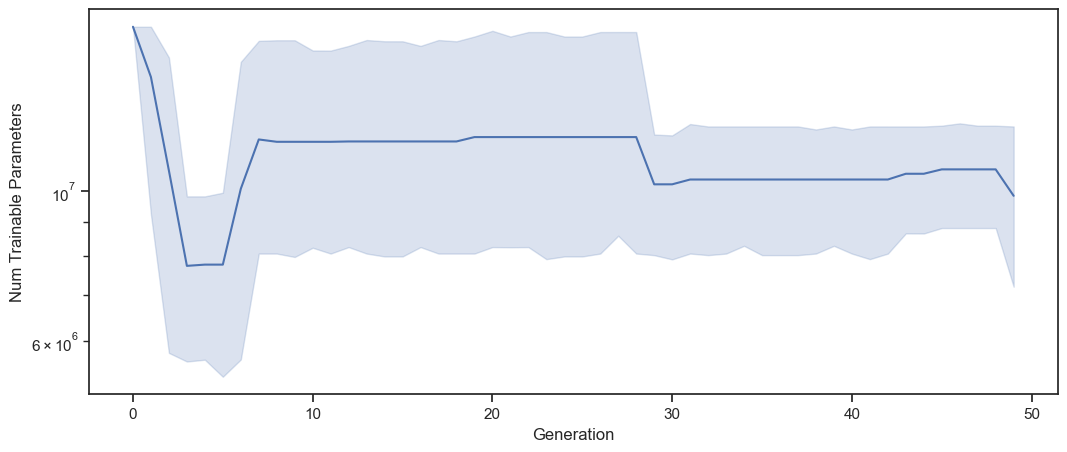

In [106]:
sn.lineplot(data, x='gen', y='n_trainable_parameters')
plt.xlabel("Generation")
plt.ylabel("Num Trainable Parameters")
plt.yscale('log')
plt.show()

In [107]:
if TEST.endswith('floats'):
    sn.swarmplot(data, x="gen", y="data_type", order=['bfloat16', 'float16', 'float32', 'float64'][::-1])
    plt.xlabel("Generation")
    plt.ylabel("Data Type")
    plt.xlim(0, 150)
    plt.savefig(f"figures/{TEST}_data_type.pdf", bbox_inches='tight')
    plt.show()


if TEST.endswith('floats'):
    data_type_percentage_per_gen = {
        'bfloat16': [],
        'float16': [],
        'float32': [],
        'float64': [],
    }

    for gen in data['gen'].unique():
        d = data[data['gen'] == gen]
        d = dict(d['data_type'].value_counts() / d['data_type'].count() * 100)
        for k in data_type_percentage_per_gen:
            data_type_percentage_per_gen[k].append(d.get(k, 0))

    generations = list(range(1, len(next(iter(data_type_percentage_per_gen.values()))) + 1))
    for data_type, percentages in data_type_percentage_per_gen.items():
        plt.plot(generations, percentages, label=data_type, linestyle='--', alpha=0.9)

    plt.xlabel("Generation")
    plt.ylabel("Percentage")
    plt.title("Percentage of Data Types")
    plt.legend(title='Data Type')
    plt.ylim(-1, 101)
    plt.xlim(0, 150)
    plt.savefig(f"figures/{TEST}_data_type_percentage.pdf", bbox_inches='tight')
    plt.show()


In [108]:
# # if TEST.endswith('floats'):
# #     sn.swarmplot(data, x="gen", y="data_type", order=['bfloat16', 'float16', 'float32', 'float64'][::-1])
# #     plt.xlabel("Generation")
# #     plt.ylabel("Data Type")
# #     plt.show()

# fig, ax1 = plt.subplots()

# sn.swarmplot(data=data, x="gen", y="data_type", order=['bfloat16', 'float16', 'float32', 'float64'][::-1], ax=ax1)
# ax1.set_xlabel("Generation")
# ax1.set_ylabel("Data Type")

# ax2 = ax1.twinx()
# sn.lineplot(data=data, x="gen", y="accuracy_0", color='r', ax=ax2, label='Accuracy', errorbar=None)
# ax2.set_ylabel('Accuracy (%)', color='r')
# ax2.tick_params(axis='y', labelcolor='r')
# ax2.set_ylim(0.8, 0.9)

# ax3 = ax1.twinx()
# ax3.spines['right'].set_position(('outward', 80))

# sn.lineplot(data=data, x="gen", y="power_test_0_mean", color='g', ax=ax3, label='Power', errorbar=None)
# ax3.set_ylabel('Power (W)', color='g')
# ax3.tick_params(axis='y', labelcolor='g')
# ax3.set_ylim(75, 100)

# plt.show()

In [109]:
numeric_cols = data.select_dtypes(include=[np.number]).columns
d = data.groupby('gen')[numeric_cols].mean()
d_std = data.groupby('gen')[numeric_cols].std()

for i in (0, d['fitness'].idxmax(), 49):
    print(f"Generation {i}")
    ind = d.iloc[i]
    ind_std = d_std.iloc[i]
    print(f"Fitness: {ind['fitness']:.4f} ± {ind_std['fitness']:.4f}")
    print(f"Accuracy 0: {ind['accuracy_0']:.4f} ± {ind_std['accuracy_0']:.4f}")
    print(f"Accuracy 1: {ind['accuracy_1']:.4f} ± {ind_std['accuracy_1']:.4f}")
    print(f"Power train: {ind['power_train']:.4f} ± {ind_std['power_train']:.4f}")
    print(f"Power test 0: {ind['power_test_0_mean']:.4f} ± {ind_std['power_test_0_mean']:.4f}")
    print(f"Power test 1: {ind['power_test_1_mean']:.4f} ± {ind_std['power_test_1_mean']:.4f}")
    print(f"Trainable parameters: {ind['n_trainable_parameters']:.4f} ± {ind_std['n_trainable_parameters']:.4f}")
    print(f"Number of layers 0: {ind['n_layers_0']:.4f} ± {ind_std['n_layers_0']:.4f}")
    print()

# calculate the differences between the two individuals
(d.iloc[49] - d.iloc[0]) / d.iloc[0] * 100

Generation 0
Fitness: 0.7558 ± 0.0988
Accuracy 0: 0.6693 ± 0.0914
Accuracy 1: 0.0865 ± 0.0078
Power train: 250.9312 ± 43.8472
Power test 0: 159.3933 ± 27.6316
Power test 1: 103.4023 ± 6.6171
Trainable parameters: 17459451.0000 ± 0.0000
Number of layers 0: 8.0000 ± 0.0000

Generation 43
Fitness: 1.0011 ± 0.1607
Accuracy 0: 0.4598 ± 0.1028
Accuracy 1: 0.4826 ± 0.0560
Power train: 275.6564 ± 8.1737
Power test 0: 171.5060 ± 17.6446
Power test 1: 162.0164 ± 22.1924
Trainable parameters: 10589637.6000 ± 2463081.4131
Number of layers 0: 11.6000 ± 4.0373

Generation 49
Fitness: 0.9734 ± 0.1495
Accuracy 0: 0.4431 ± 0.0996
Accuracy 1: 0.4704 ± 0.0517
Power train: 272.7016 ± 11.4521
Power test 0: 168.1266 ± 16.2474
Power test 1: 154.7209 ± 21.3188
Trainable parameters: 9824726.6000 ± 3353750.2477
Number of layers 0: 11.4000 ± 4.1593



run                                 0.000000
gen                                      inf
id                                       inf
num_epochs                        503.500000
fitness                            28.791749
n_trainable_parameters            -43.728319
total_epochs_trained              503.500000
total_training_time_allocated    2560.000000
training_time_spent               800.529324
accuracy_0                        -33.801470
accuracy_1                        443.940796
n_layers_0                         42.500000
n_layers_1                        320.000000
power_train                         8.675822
power_test_0_mean                   5.479102
power_test_0_std                  -12.679773
power_test_1_mean                  49.630029
power_test_1_std                   11.657608
energy_train                       92.420106
energy_test_0_mean                  9.472926
energy_test_0_std                  29.851299
energy_test_1_mean                104.003580
energy_tes

In [110]:
best_idx = data['fitness'].idxmax()

for i in (0, best_idx):
    print(f"Generation {data.iloc[i]['gen']}")
    ind = data.iloc[i]
    print(f"Fitness: {ind['fitness']:.4f}")
    print(f"Accuracy 0: {ind['accuracy_0']:.4f}")
    print(f"Accuracy 1: {ind['accuracy_1']:.4f}")
    print(f"Power train: {ind['power_train']:.4f}")
    print(f"Power test 0: {ind['power_test_0_mean']:.4f}")
    print(f"Power test 1: {ind['power_test_1_mean']:.4f}")
    print(f"Trainable parameters: {ind['n_trainable_parameters']:.4f}")
    print(f"Number of layers 0: {ind['n_layers_0']:.4f}")
    print()

# calculate the differences between the two individuals
d = data[data.select_dtypes(include=[np.number]).columns]
(d.iloc[best_idx] - d.iloc[0]) / d.iloc[0] * 100

Generation 0
Fitness: 0.8078
Accuracy 0: 0.7202
Accuracy 1: 0.0876
Power train: 269.4222
Power test 0: 161.5866
Power test 1: 96.2053
Trainable parameters: 17459451.0000
Number of layers 0: 8.0000

Generation 33
Fitness: 1.1277
Accuracy 0: 0.5244
Accuracy 1: 0.5248
Power train: 176.5290
Power test 0: 127.4495
Power test 1: 131.3128
Trainable parameters: 9410973.0000
Number of layers 0: 10.0000



run                                      inf
gen                                      inf
id                                       inf
num_epochs                        479.487179
fitness                            39.596739
n_trainable_parameters            -46.098116
total_epochs_trained              479.487179
total_training_time_allocated    1900.000000
training_time_spent               899.622512
accuracy_0                        -27.186893
accuracy_1                        499.086758
n_layers_0                         25.000000
n_layers_1                        300.000000
power_train                       -34.478686
power_test_0_mean                 -21.126213
power_test_0_std                  -42.623127
power_test_1_mean                  36.492323
power_test_1_std                   18.854146
energy_train                       53.090408
energy_test_0_mean                 76.244353
energy_test_0_std                  12.575284
energy_test_1_mean                195.408776
energy_tes